## Import Packages

In [1]:
#importing some useful packages
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2
from IPython.display import HTML

%matplotlib inline

## Read in an Image

This image is: <class 'numpy.ndarray'> with dimensions: (540, 960, 3)


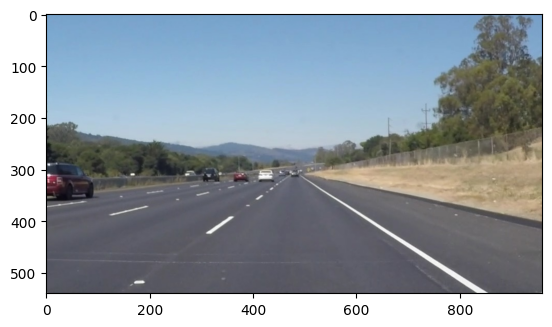

In [2]:
image = mpimg.imread('test_images/solidWhiteRight.jpg')
print('This image is:', type(image), 'with dimensions:', image.shape)
plt.imshow(image) 

## Helper Functions

In [3]:
import math

def grayscale(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
def canny(img, low_threshold, high_threshold):
    return cv2.Canny(img, low_threshold, high_threshold)

def gaussian_blur(img, kernel_size):
    """Applies a Gaussian Noise kernel"""
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)

def region_of_interest(img, vertices):
    mask = np.zeros_like(img)   
    if len(img.shape) > 2:
        channel_count = img.shape[2]  # i.e. 3 or 4 depending on your image
        ignore_mask_color = (255,) * channel_count
    else:
        ignore_mask_color = 255
    cv2.fillPoly(mask, vertices, ignore_mask_color)
    masked_image = cv2.bitwise_and(img, mask)
    return masked_image


def draw_lines(img, lines, color=[255, 0, 0], thickness=2):
    for line in lines:
        for x1,y1,x2,y2 in line:
            cv2.line(img, (x1, y1), (x2, y2), color, thickness)

def hough_lines(img, rho, theta, threshold, min_line_len, max_line_gap):
    
    lines = cv2.HoughLinesP(img, rho, theta, threshold, np.array([]), minLineLength=min_line_len, maxLineGap=max_line_gap)
    line_img = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
    draw_lines(line_img, lines)
    return line_img


def weighted_img(img, initial_img, α=0.8, β=1., γ=0.):
    return cv2.addWeighted(initial_img, α, img, β, γ)

## Test Images

Build your pipeline to work on the images in the directory "test_images"  
**You should make sure your pipeline works well on these images before you try the videos.**

In [4]:
import os
os.listdir("test_images/")

['solidYellowCurve2.jpg',
 'solidWhiteCurve.jpg',
 'solidYellowCurve.jpg',
 'solidWhiteRight.jpg',
 'solidYellowLeft.jpg',
 'whiteCarLaneSwitch.jpg']

## Build a Lane Finding Pipeline



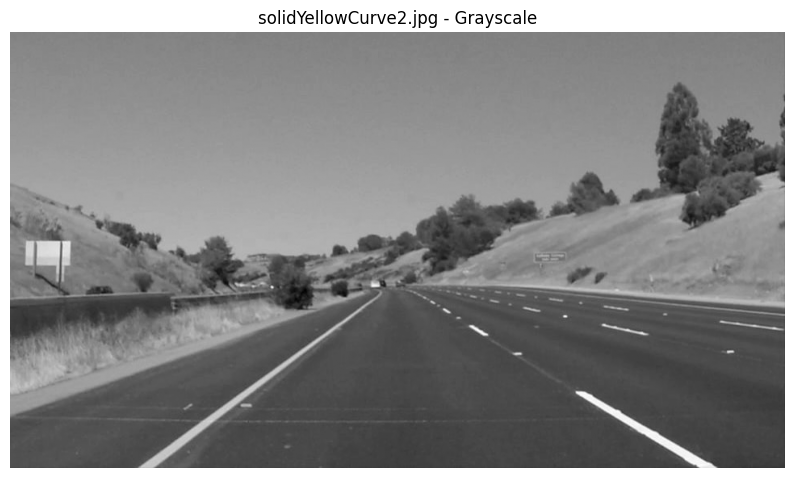

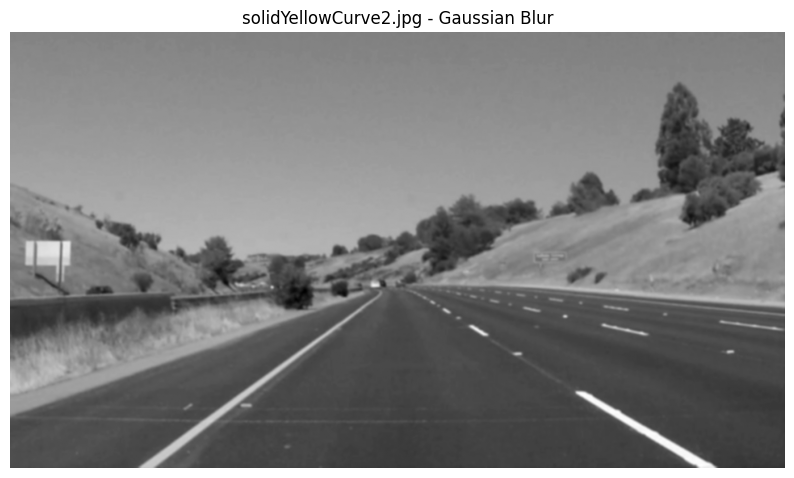

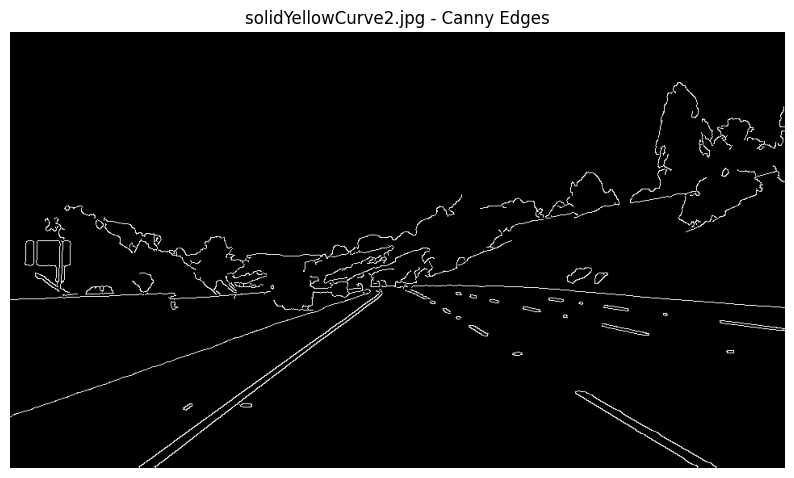

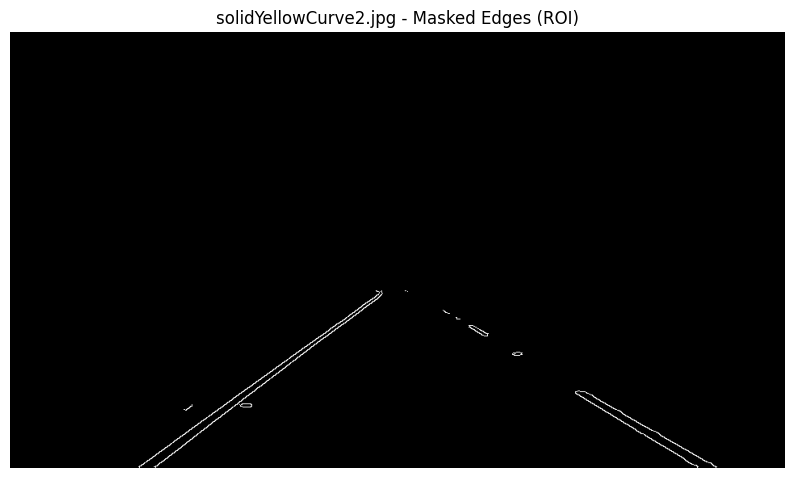

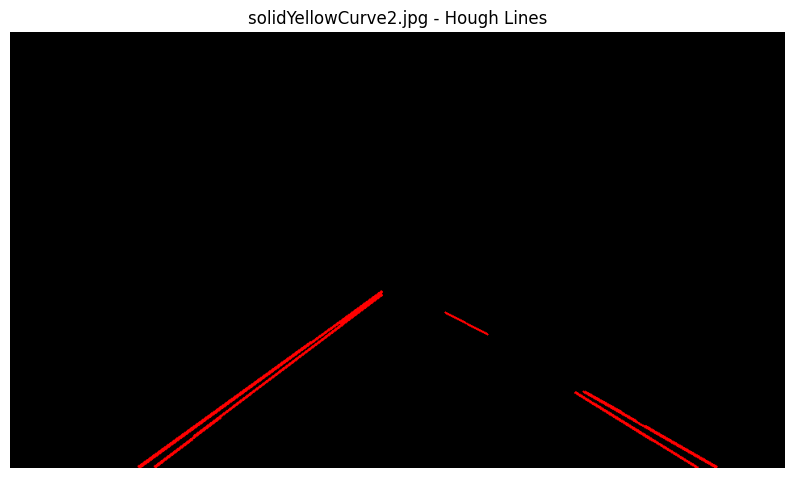

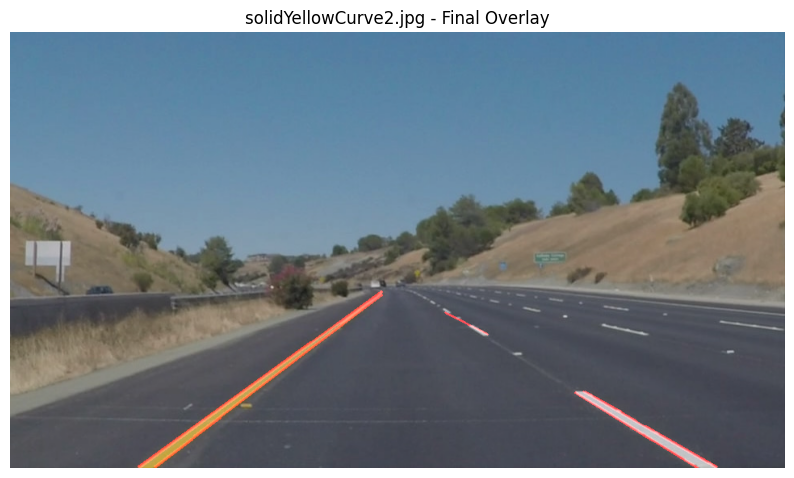

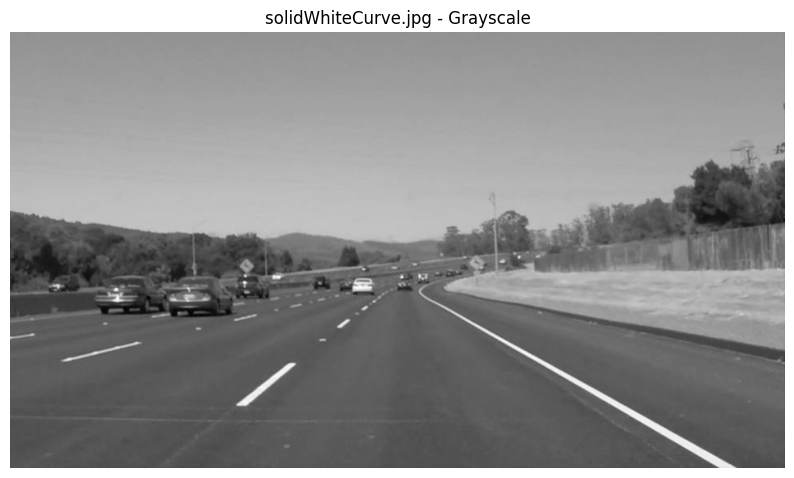

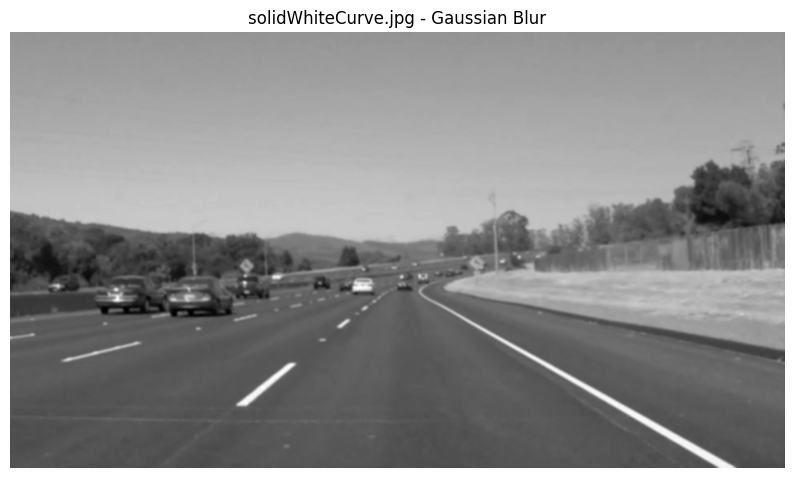

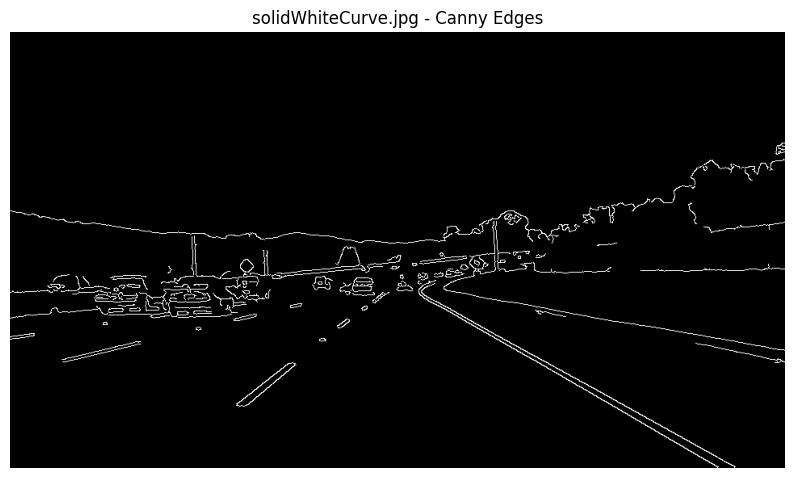

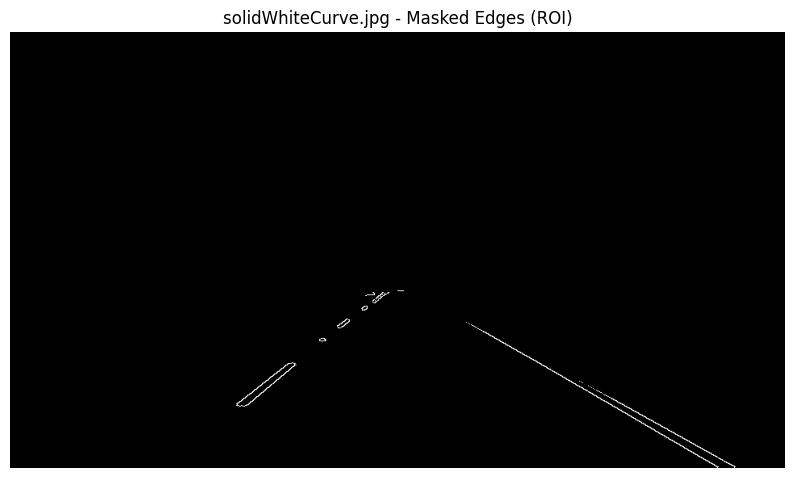

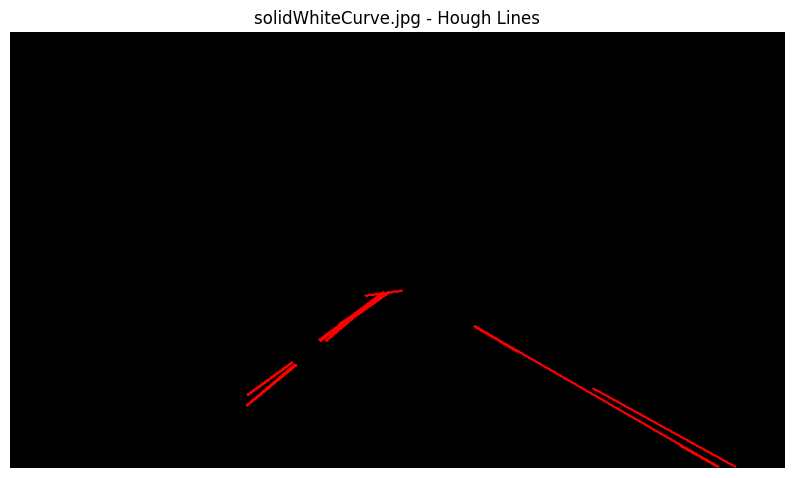

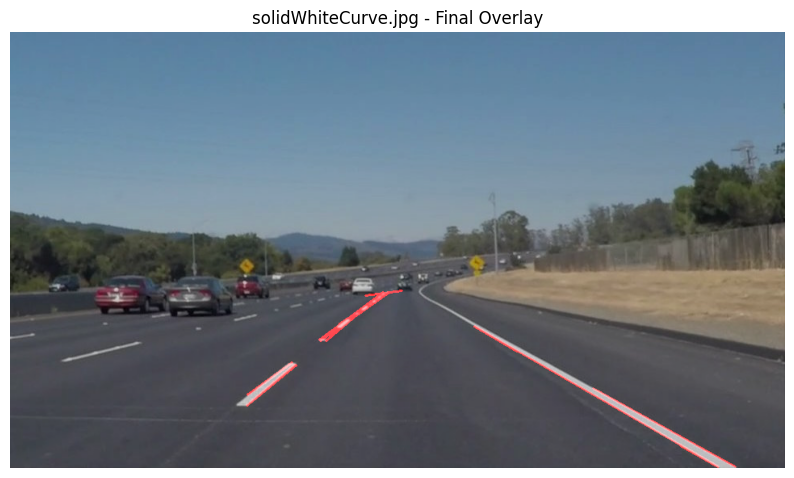

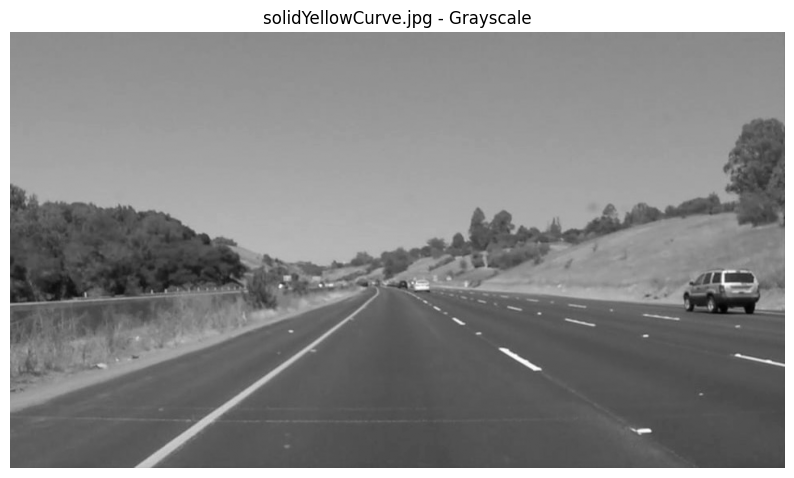

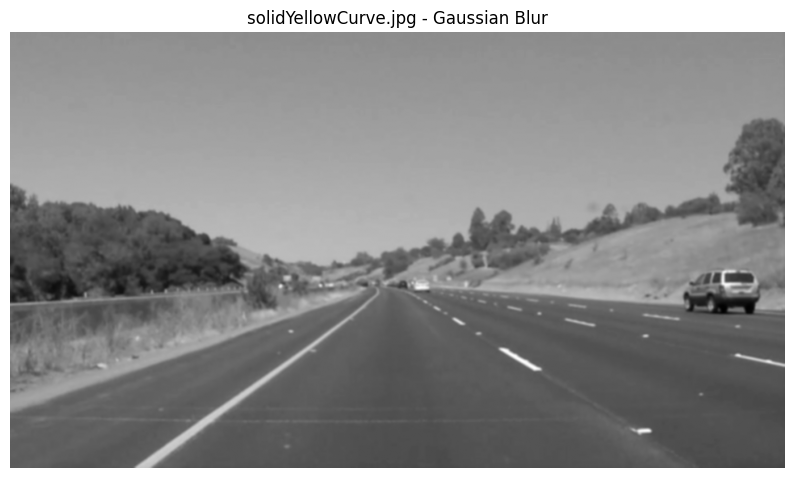

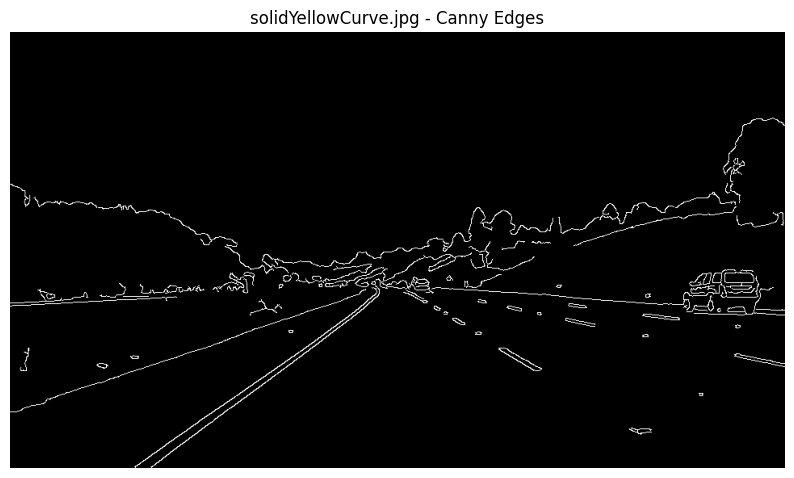

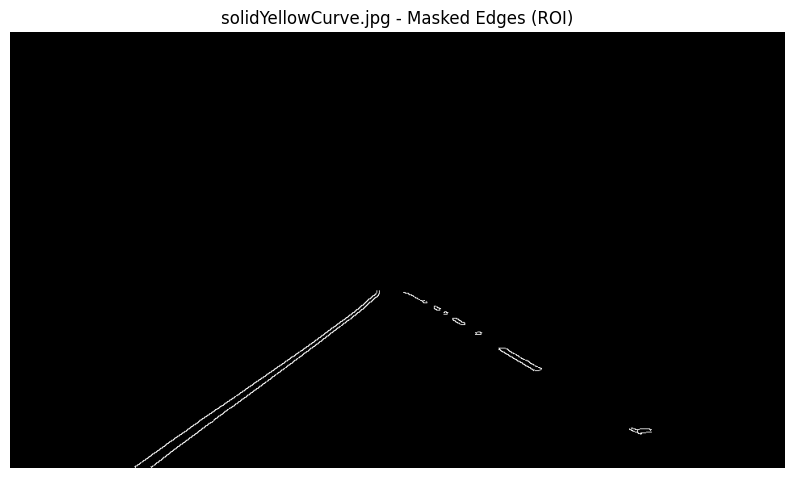

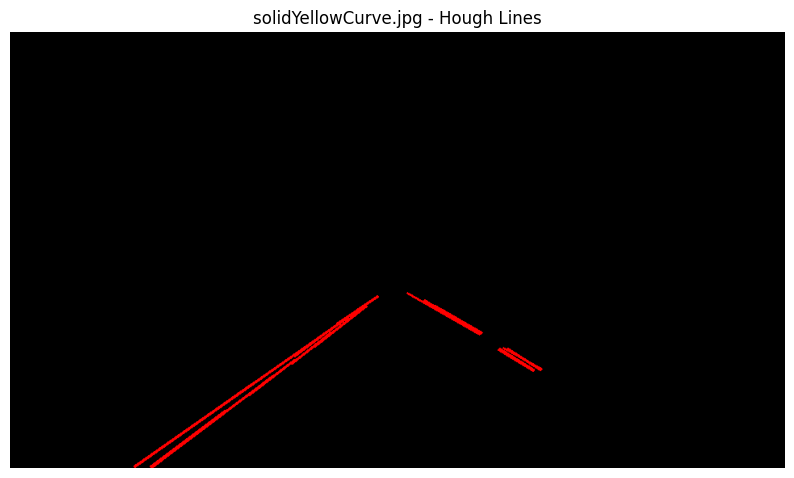

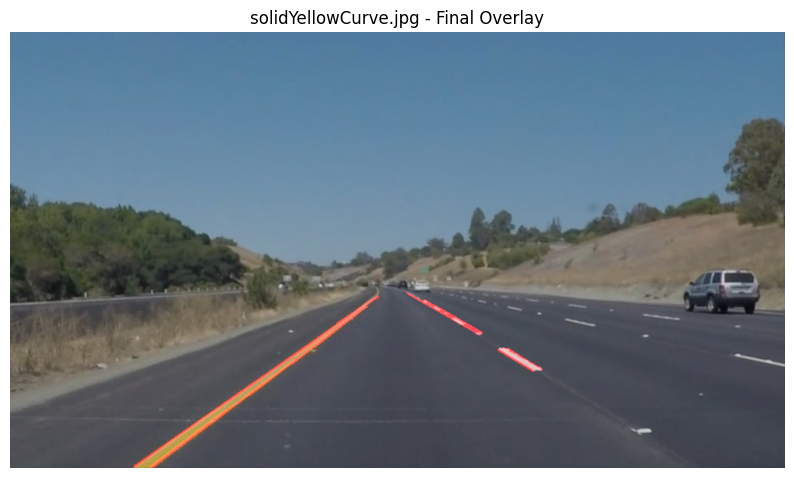

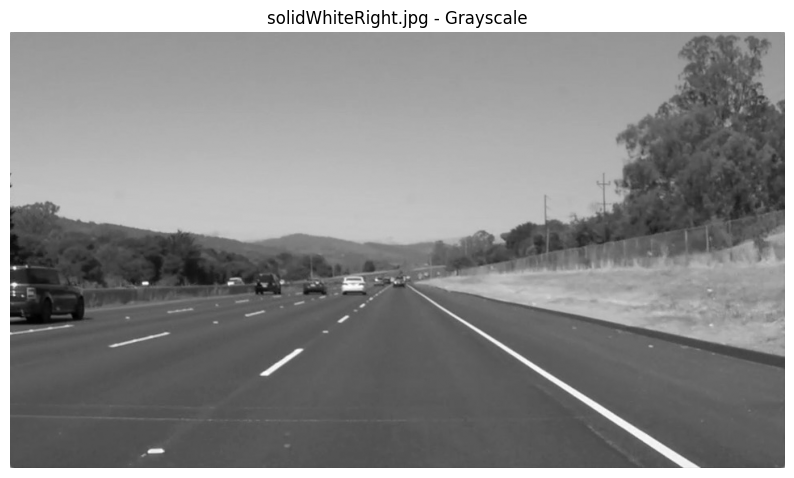

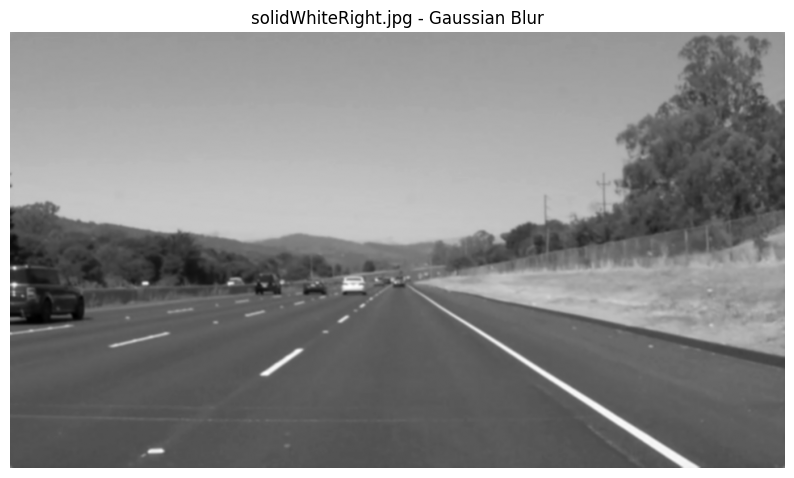

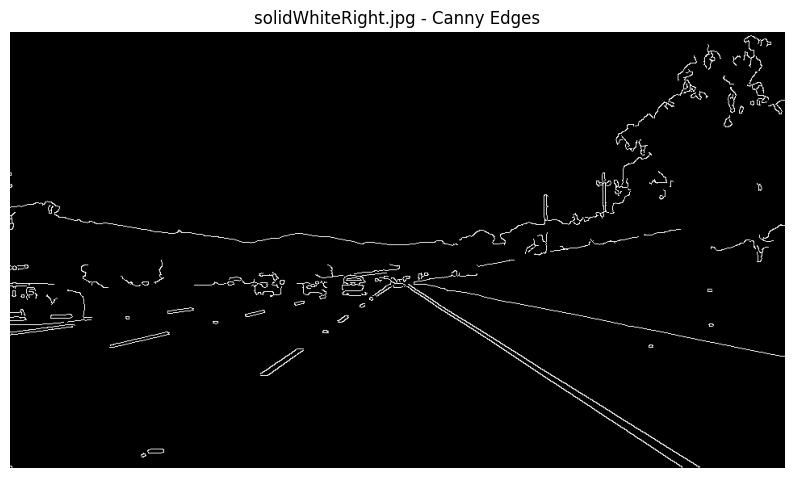

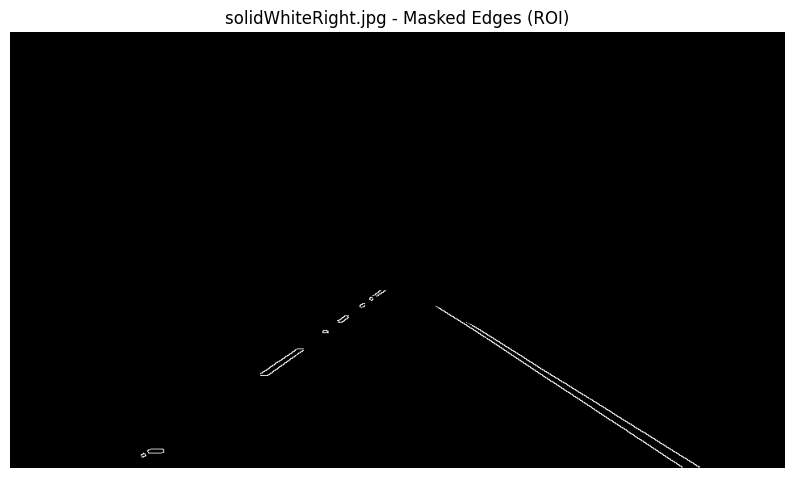

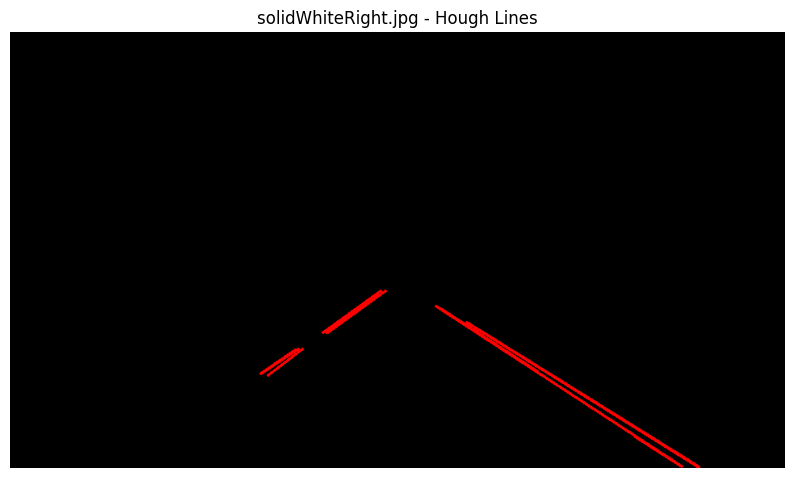

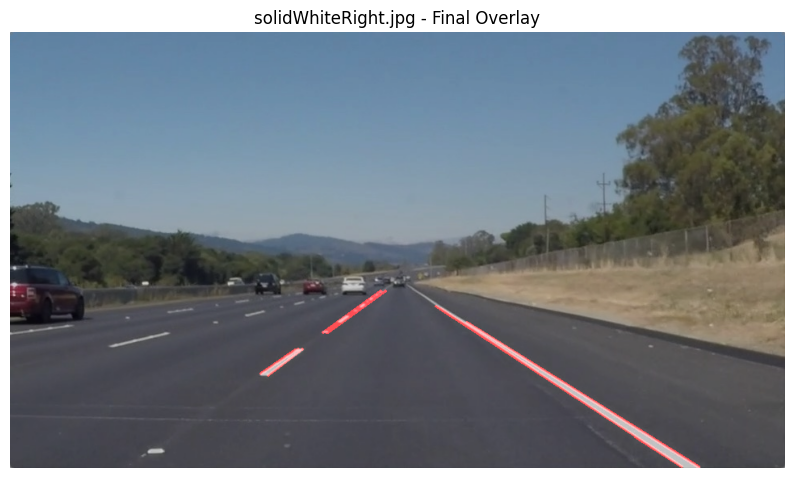

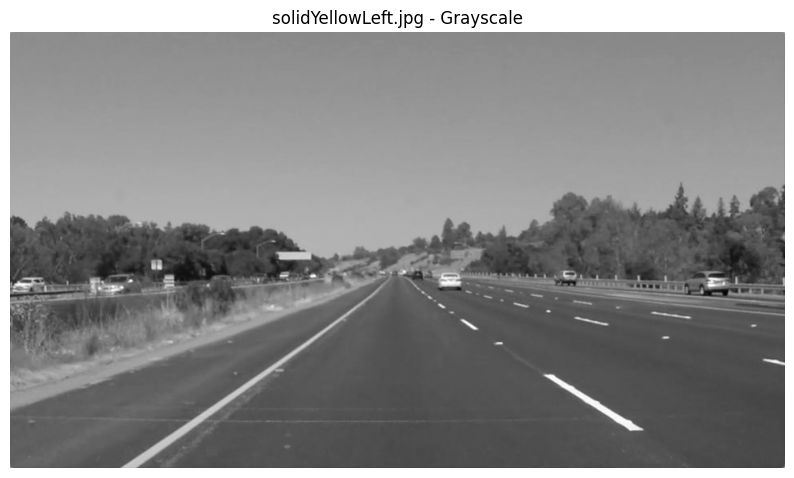

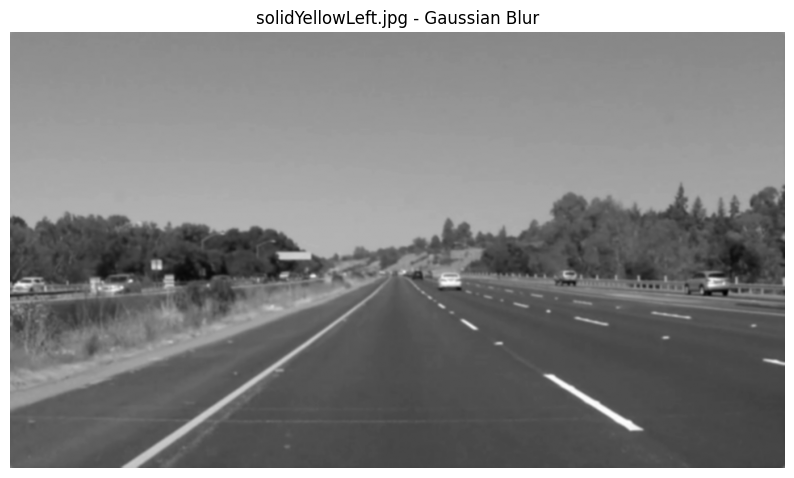

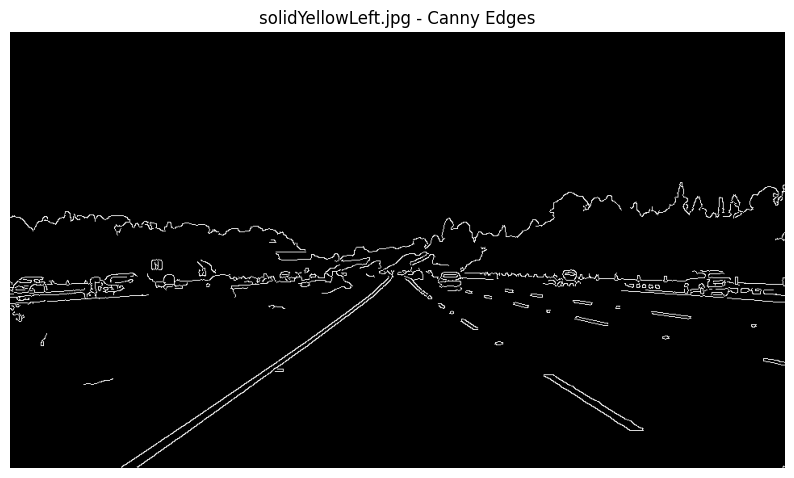

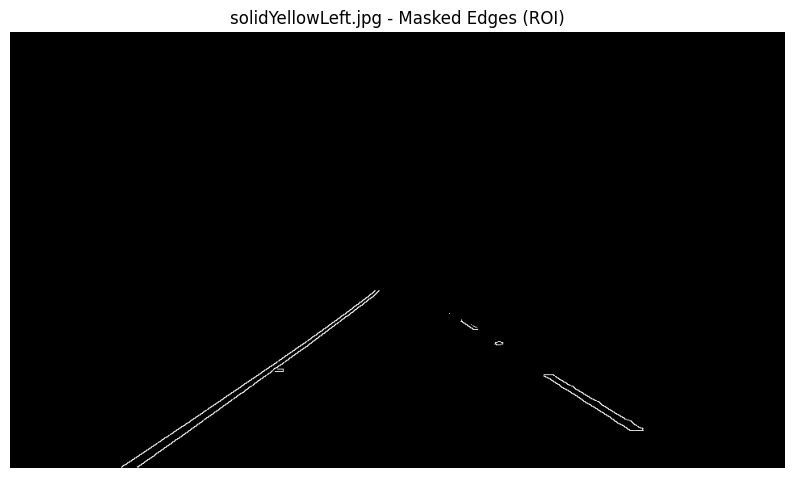

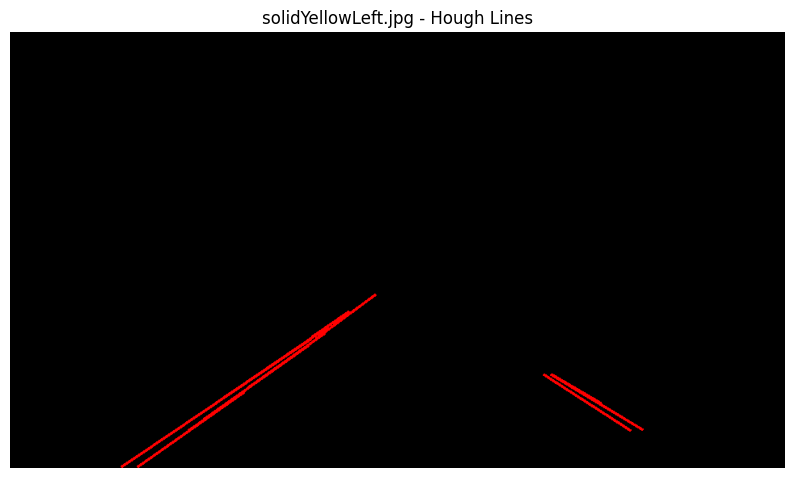

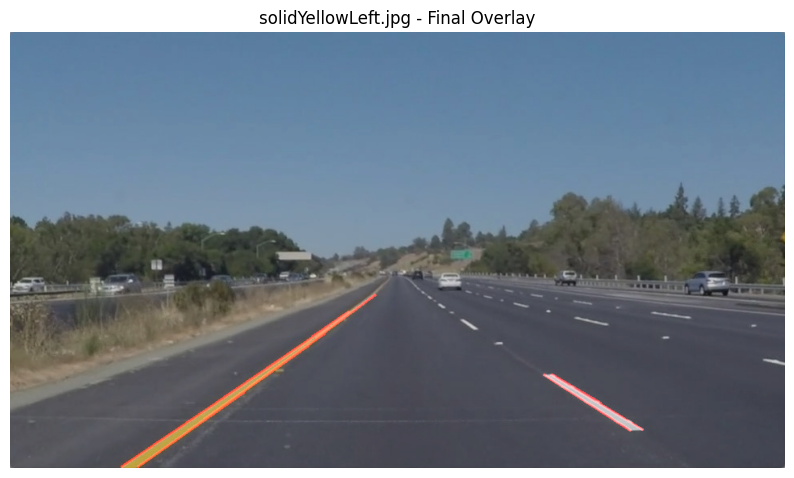

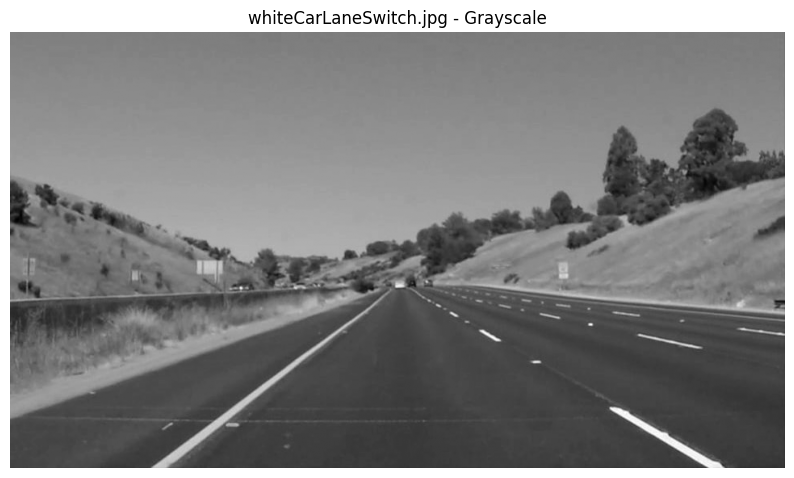

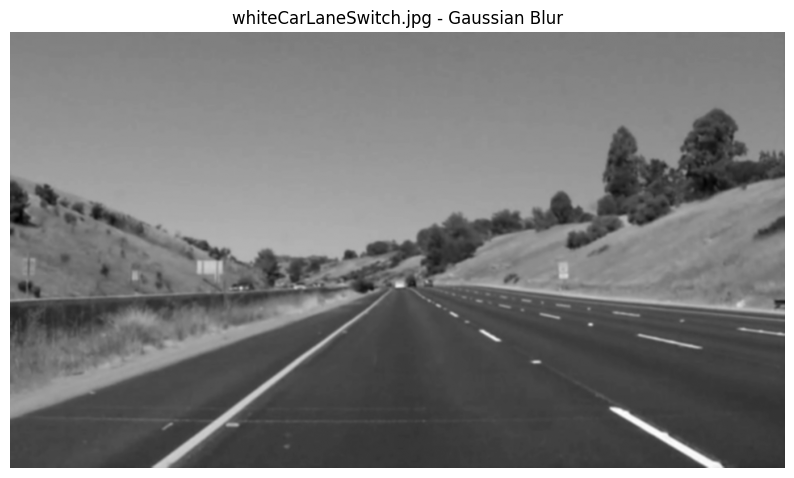

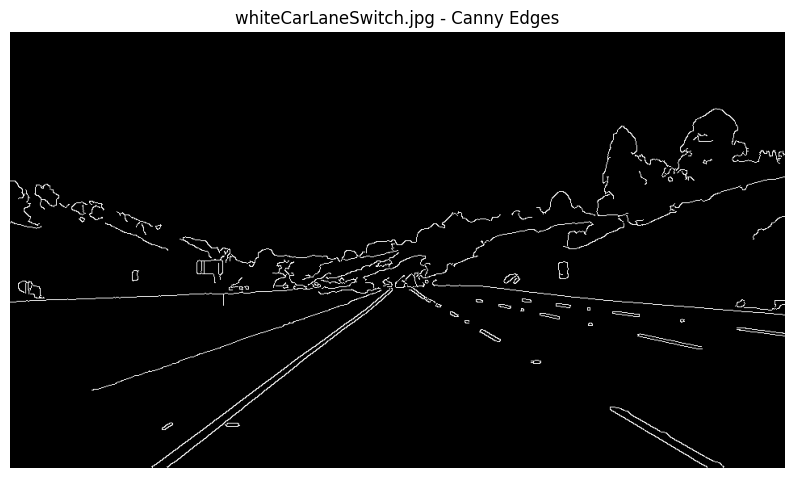

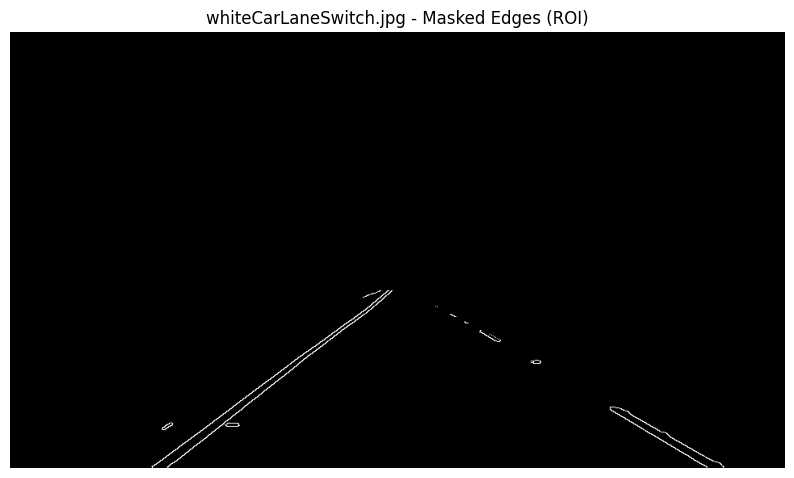

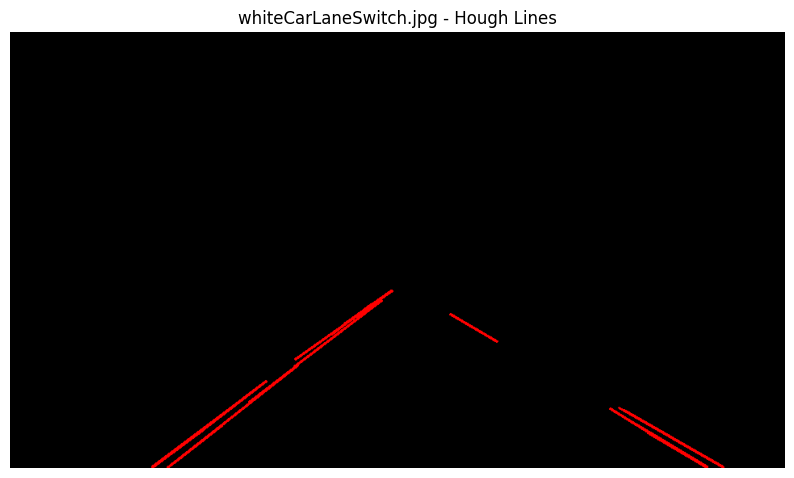

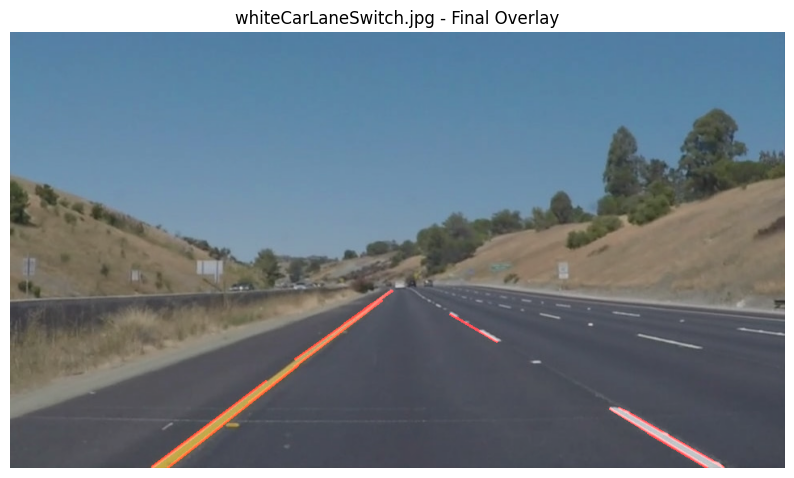

In [5]:
# Make output directory if it doesn't exist
output_dir = "test_images_output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Loop through all images
for filename in os.listdir("test_images/"):
    if filename.endswith(".jpg") or filename.endswith(".png"):
        image = mpimg.imread(os.path.join("test_images", filename))
        
        # Step 1: Grayscale
        gray = grayscale(image)
        plt.figure(figsize=(10,6))
        plt.imshow(gray, cmap='gray')
        plt.title(f'{filename} - Grayscale')
        plt.axis('off')
        plt.show()
        
        # Step 2: Gaussian blur
        blur_gray = gaussian_blur(gray, 5)
        plt.figure(figsize=(10,6))
        plt.imshow(blur_gray, cmap='gray')
        plt.title(f'{filename} - Gaussian Blur')
        plt.axis('off')
        plt.show()
        
        # Step 3: Canny edge detection
        edges = canny(blur_gray, 50, 150)
        plt.figure(figsize=(10,6))
        plt.imshow(edges, cmap='gray')
        plt.title(f'{filename} - Canny Edges')
        plt.axis('off')
        plt.show()
        
        # Step 4: Region of Interest mask
        imshape = image.shape
        vertices = np.array([[(100, imshape[0]), (450, 320), (490, 320), (imshape[1]-50, imshape[0])]], dtype=np.int32)
        masked_edges = region_of_interest(edges, vertices)
        plt.figure(figsize=(10,6))
        plt.imshow(masked_edges, cmap='gray')
        plt.title(f'{filename} - Masked Edges (ROI)')
        plt.axis('off')
        plt.show()
        
        # Step 5: Hough lines
        line_image = hough_lines(masked_edges, rho=2, theta=np.pi/180, threshold=15, min_line_len=40, max_line_gap=20)
        plt.figure(figsize=(10,6))
        plt.imshow(line_image)
        plt.title(f'{filename} - Hough Lines')
        plt.axis('off')
        plt.show()
        
        # Step 6: Overlay lines on original image
        combo = weighted_img(line_image, image, α=0.8, β=1., γ=0.)
        plt.figure(figsize=(10,6))
        plt.imshow(combo)
        plt.title(f'{filename} - Final Overlay')
        plt.axis('off')
        plt.show()
        
        # Save final output
        mpimg.imsave(os.path.join(output_dir, filename), combo)


In [6]:
# Import everything needed to edit/save/watch video clips
from moviepy.editor import VideoFileClip
from IPython.display import HTML

In [10]:
def process_image(image):
    # 1. Grayscale
    gray = grayscale(image)

    # 2. Blur
    blur = gaussian_blur(gray, 5)

    # 3. Edge detection
    edges = canny(blur, 50, 150)

    # 4. Region of Interest
    imshape = image.shape
    vertices = np.array([[
        (0, imshape[0]),
        (imshape[1], imshape[0]),
        (imshape[1]//2, imshape[0]//2)
    ]], dtype=np.int32)

    masked_edges = region_of_interest(edges, vertices)

    # 5. Hough lines
    line_image = hough_lines(
        masked_edges,
        rho=2,
        theta=np.pi/180,
        threshold=50,
        min_line_len=40,
        max_line_gap=100
    )

    # 6. Combine with original image
    result = weighted_img(line_image, image)

    return result


Let's try the one with the solid white lane on the right first ...

In [11]:
white_output = 'test_videos_output/solidWhiteRight.mp4'
clip1 = VideoFileClip("test_videos/solidWhiteRight.mp4")
white_clip = clip1.fl_image(process_image) #NOTE: this function expects color images!!
%time white_clip.write_videofile(white_output, audio=False)

Moviepy - Building video test_videos_output/solidWhiteRight.mp4.
Moviepy - Writing video test_videos_output/solidWhiteRight.mp4



Moviepy - Done !
Moviepy - video ready test_videos_output/solidWhiteRight.mp4
CPU times: user 2.63 s, sys: 929 ms, total: 3.56 s
Wall time: 8.21 s


Play the video inline, or if you prefer find the video in your filesystem (should be in the same directory) and play it in your video player of choice.

In [23]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format(white_output))

In [14]:
yellow_output = 'test_videos_output/solidYellowLeft.mp4'
clip2 = VideoFileClip('test_videos/solidYellowLeft.mp4')
yellow_clip = clip2.fl_image(process_image)
%time yellow_clip.write_videofile(yellow_output, audio=False)

Moviepy - Building video test_videos_output/solidYellowLeft.mp4.
Moviepy - Writing video test_videos_output/solidYellowLeft.mp4



Moviepy - Done !
Moviepy - video ready test_videos_output/solidYellowLeft.mp4
CPU times: user 8.63 s, sys: 2.98 s, total: 11.6 s
Wall time: 30.7 s


In [16]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format(yellow_output))

In [17]:
challenge_output = 'test_videos_output/challenge.mp4'
clip3 = VideoFileClip('test_videos/challenge.mp4')
challenge_clip = clip3.fl_image(process_image)
%time challenge_clip.write_videofile(challenge_output, audio=False)

Moviepy - Building video test_videos_output/challenge.mp4.
Moviepy - Writing video test_videos_output/challenge.mp4



Moviepy - Done !
Moviepy - video ready test_videos_output/challenge.mp4
CPU times: user 6.35 s, sys: 1.7 s, total: 8.06 s
Wall time: 22.2 s


In [18]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format(challenge_output))